In [1]:
import csv

students = [
    ["Student_ID", "Name", "Python", "DBMS", "Maths", "Attendance"],
    [101, "Aman", 78, 85, 90, 82],
    [102, "Riya", 92, 88, 95, 91],
    [103, "Kabir", 65, 72, 68, 70],
    [104, "Neha", 88, 79, 84, 76],
    [105, "Arjun", 55, 60, 58, 68]
]

with open("student_marks.csv", "w", newline="") as file:
    writer = csv.writer(file)
    writer.writerows(students)

print("CSV file created successfully.")

CSV file created successfully.


In [2]:
import csv

def calculate_average(python, dbms, maths):
    return (python + dbms + maths) / 3


records = []

with open("student_marks.csv", "r") as file:
    reader = csv.DictReader(file)

    for row in reader:
        row["Python"] = int(row["Python"])
        row["DBMS"] = int(row["DBMS"])
        row["Maths"] = int(row["Maths"])
        row["Attendance"] = int(row["Attendance"])

        row["Average"] = calculate_average(
            row["Python"],
            row["DBMS"],
            row["Maths"]
        )

        records.append(row)


# 1. Display all student records
print("Student Records:")
for student in records:
    print(student)


# 2. Find student with highest average
top_student = max(records, key=lambda x: x["Average"])

print("\nStudent with highest average:")
print(top_student["Name"], "=", round(top_student["Average"], 2))


# 3. Highest and lowest marks in each subject
subjects = ["Python", "DBMS", "Maths"]

print("\nHighest and Lowest Marks:")
for subject in subjects:
    marks = [student[subject] for student in records]

    print(
        subject,
        "Highest =", max(marks),
        "Lowest =", min(marks)
    )


# 4. Students with attendance below 75%
print("\nStudents with attendance below 75%:")

for student in records:
    if student["Attendance"] < 75:
        print(student["Name"], "-", student["Attendance"], "%")


# 5. Count passed and failed students
# Passing criterion: average marks >= 50

passed = 0
failed = 0

for student in records:
    if student["Average"] >= 50:
        passed += 1
    else:
        failed += 1

print("\nPassed students:", passed)
print("Failed students:", failed)


# 6. Write final analysis to a new CSV file
with open("student_analysis.csv", "w", newline="") as file:
    fields = [
        "Student_ID", "Name", "Python", "DBMS",
        "Maths", "Attendance", "Average"
    ]

    writer = csv.DictWriter(file, fieldnames=fields)
    writer.writeheader()

    for student in records:
        writer.writerow(student)

print("\nFinal analysis saved to student_analysis.csv")

Student Records:
{'Student_ID': '101', 'Name': 'Aman', 'Python': 78, 'DBMS': 85, 'Maths': 90, 'Attendance': 82, 'Average': 84.33333333333333}
{'Student_ID': '102', 'Name': 'Riya', 'Python': 92, 'DBMS': 88, 'Maths': 95, 'Attendance': 91, 'Average': 91.66666666666667}
{'Student_ID': '103', 'Name': 'Kabir', 'Python': 65, 'DBMS': 72, 'Maths': 68, 'Attendance': 70, 'Average': 68.33333333333333}
{'Student_ID': '104', 'Name': 'Neha', 'Python': 88, 'DBMS': 79, 'Maths': 84, 'Attendance': 76, 'Average': 83.66666666666667}
{'Student_ID': '105', 'Name': 'Arjun', 'Python': 55, 'DBMS': 60, 'Maths': 58, 'Attendance': 68, 'Average': 57.666666666666664}

Student with highest average:
Riya = 91.67

Highest and Lowest Marks:
Python Highest = 92 Lowest = 55
DBMS Highest = 88 Lowest = 60
Maths Highest = 95 Lowest = 58

Students with attendance below 75%:
Kabir - 70 %
Arjun - 68 %

Passed students: 5
Failed students: 0

Final analysis saved to student_analysis.csv


In [3]:
# Question 2

In [4]:
import csv

employees = [
    ["Emp_ID", "Name", "Department", "Basic_Salary", "Bonus", "Experience"],
    [201, "Aman", "IT", 55000, 8000, 4],
    [202, "Riya", "HR", 48000, 6000, 6],
    [203, "Kabir", "IT", 72000, 10000, 8],
    [204, "Neha", "Finance", 65000, 9000, 5],
    [205, "Arjun", "HR", 52000, 7000, 7]
]

with open("employee_salary.csv", "w", newline="") as file:
    writer = csv.writer(file)
    writer.writerows(employees)

print("CSV file created successfully.")

CSV file created successfully.


In [5]:
import csv

employees = []

with open("employee_salary.csv", "r") as file:
    reader = csv.DictReader(file)

    for row in reader:
        row["Basic_Salary"] = int(row["Basic_Salary"])
        row["Bonus"] = int(row["Bonus"])
        row["Experience"] = int(row["Experience"])

        row["Total_Salary"] = row["Basic_Salary"] + row["Bonus"]

        employees.append(row)


# 1. Display all employee records
print("Employee Records:")
for employee in employees:
    print(employee)


# 2. Find highest-paid employee
highest_paid = max(employees, key=lambda x: x["Total_Salary"])

print("\nHighest-paid employee:")
print(
    highest_paid["Name"],
    "=",
    highest_paid["Total_Salary"]
)


# 3. Department-wise average salary
department_data = {}

for employee in employees:
    department = employee["Department"]
    salary = employee["Total_Salary"]

    if department not in department_data:
        department_data[department] = []

    department_data[department].append(salary)

print("\nDepartment-wise average salary:")

for department, salaries in department_data.items():
    average = sum(salaries) / len(salaries)
    print(department, "=", round(average, 2))


# 4. Employees having more than 5 years of experience
print("\nEmployees with more than 5 years experience:")

for employee in employees:
    if employee["Experience"] > 5:
        print(employee["Name"], "-", employee["Experience"], "years")


# 5. Sort employees according to total salary
employees.sort(key=lambda x: x["Total_Salary"], reverse=True)

print("\nEmployees sorted by total salary:")

for employee in employees:
    print(employee["Name"], "-", employee["Total_Salary"])


# 6. Save sorted result into another CSV file
with open("sorted_employee_salary.csv", "w", newline="") as file:
    fields = [
        "Emp_ID", "Name", "Department",
        "Basic_Salary", "Bonus",
        "Experience", "Total_Salary"
    ]

    writer = csv.DictWriter(file, fieldnames=fields)
    writer.writeheader()
    writer.writerows(employees)

print("\nSorted result saved to sorted_employee_salary.csv")

Employee Records:
{'Emp_ID': '201', 'Name': 'Aman', 'Department': 'IT', 'Basic_Salary': 55000, 'Bonus': 8000, 'Experience': 4, 'Total_Salary': 63000}
{'Emp_ID': '202', 'Name': 'Riya', 'Department': 'HR', 'Basic_Salary': 48000, 'Bonus': 6000, 'Experience': 6, 'Total_Salary': 54000}
{'Emp_ID': '203', 'Name': 'Kabir', 'Department': 'IT', 'Basic_Salary': 72000, 'Bonus': 10000, 'Experience': 8, 'Total_Salary': 82000}
{'Emp_ID': '204', 'Name': 'Neha', 'Department': 'Finance', 'Basic_Salary': 65000, 'Bonus': 9000, 'Experience': 5, 'Total_Salary': 74000}
{'Emp_ID': '205', 'Name': 'Arjun', 'Department': 'HR', 'Basic_Salary': 52000, 'Bonus': 7000, 'Experience': 7, 'Total_Salary': 59000}

Highest-paid employee:
Kabir = 82000

Department-wise average salary:
IT = 72500.0
HR = 56500.0
Finance = 74000.0

Employees with more than 5 years experience:
Riya - 6 years
Kabir - 8 years
Arjun - 7 years

Employees sorted by total salary:
Kabir - 82000
Neha - 74000
Aman - 63000
Arjun - 59000
Riya - 54000

Sor

In [8]:
#Question 3

In [6]:
import csv

sales = [
    ["Order_ID", "Product", "Category", "Quantity", "Price", "Region"],
    [301, "Laptop", "Electronics", 3, 55000, "North"],
    [302, "Mouse", "Accessories", 10, 800, "South"],
    [303, "Keyboard", "Accessories", 7, 1500, "East"],
    [304, "Laptop", "Electronics", 2, 55000, "West"],
    [305, "Headphones", "Accessories", 8, 2500, "North"],
    [306, "Monitor", "Electronics", 4, 18000, "South"],
    [307, "Mouse", "Accessories", 12, 800, "East"]
]

with open("sales_data.csv", "w", newline="") as file:
    writer = csv.writer(file)
    writer.writerows(sales)

print("CSV file created successfully.")

CSV file created successfully.


In [7]:
import csv

orders = []

with open("sales_data.csv", "r") as file:
    reader = csv.DictReader(file)

    for row in reader:
        row["Quantity"] = int(row["Quantity"])
        row["Price"] = float(row["Price"])

        # Total sales for the order
        row["Revenue"] = row["Quantity"] * row["Price"]

        orders.append(row)


# 1. Display total sales for every order
print("Order-wise Sales:")

for order in orders:
    print(
        order["Order_ID"],
        "->",
        order["Product"],
        "=",
        order["Revenue"]
    )


# 2. Best-selling product based on quantity
product_quantity = {}

for order in orders:
    product = order["Product"]

    product_quantity[product] = (
        product_quantity.get(product, 0) + order["Quantity"]
    )

best_product = max(product_quantity, key=product_quantity.get)

print("\nBest-selling product:")
print(best_product, "=", product_quantity[best_product], "units")


# 3. Product generating maximum revenue
product_revenue = {}

for order in orders:
    product = order["Product"]

    product_revenue[product] = (
        product_revenue.get(product, 0) + order["Revenue"]
    )

top_revenue_product = max(product_revenue, key=product_revenue.get)

print("\nProduct generating maximum revenue:")
print(
    top_revenue_product,
    "=",
    product_revenue[top_revenue_product]
)


# 4. Region-wise revenue
region_revenue = {}

for order in orders:
    region = order["Region"]

    region_revenue[region] = (
        region_revenue.get(region, 0) + order["Revenue"]
    )

print("\nRegion-wise Revenue:")

for region, revenue in region_revenue.items():
    print(region, "=", revenue)


# 5. Category-wise sales
category_sales = {}

for order in orders:
    category = order["Category"]

    category_sales[category] = (
        category_sales.get(category, 0) + order["Revenue"]
    )

print("\nCategory-wise Sales:")

for category, sales_amount in category_sales.items():
    print(category, "=", sales_amount)


# 6. Top 5 orders by revenue
top_orders = sorted(
    orders,
    key=lambda x: x["Revenue"],
    reverse=True
)[:5]

print("\nTop 5 Orders by Revenue:")

for order in top_orders:
    print(order["Order_ID"], "=", order["Revenue"])


# 7. Save summarized results to CSV
with open("sales_summary.csv", "w", newline="") as file:
    writer = csv.writer(file)

    writer.writerow(["Product", "Total Quantity", "Total Revenue"])

    for product in product_quantity:
        writer.writerow([
            product,
            product_quantity[product],
            product_revenue.get(product, 0)
        ])

print("\nSummary saved to sales_summary.csv")

Order-wise Sales:
301 -> Laptop = 165000.0
302 -> Mouse = 8000.0
303 -> Keyboard = 10500.0
304 -> Laptop = 110000.0
305 -> Headphones = 20000.0
306 -> Monitor = 72000.0
307 -> Mouse = 9600.0

Best-selling product:
Mouse = 22 units

Product generating maximum revenue:
Laptop = 275000.0

Region-wise Revenue:
North = 185000.0
South = 80000.0
East = 20100.0
West = 110000.0

Category-wise Sales:
Electronics = 347000.0
Accessories = 48100.0

Top 5 Orders by Revenue:
301 = 165000.0
304 = 110000.0
306 = 72000.0
305 = 20000.0
303 = 10500.0

Summary saved to sales_summary.csv


In [9]:
#Question 4

In [10]:
import csv

weather = [
    ["Date", "City", "Temperature", "Humidity", "Rainfall"],
    ["2026-01-01", "Delhi", 18, 65, 0],
    ["2026-01-02", "Delhi", 16, 72, 12],
    ["2026-01-01", "Mumbai", 28, 78, 15],
    ["2026-01-02", "Mumbai", 27, 82, 25],
    ["2026-01-01", "Chandigarh", 14, 68, 5],
    ["2026-01-02", "Chandigarh", 13, 74, 18],
    ["2026-01-03", "Delhi", 20, 60, 8],
    ["2026-01-03", "Mumbai", 29, 76, 0],
    ["2026-01-03", "Chandigarh", 17, 66, 0]
]

with open("weather_data.csv", "w", newline="") as file:
    writer = csv.writer(file)
    writer.writerows(weather)

print("CSV file created successfully.")

CSV file created successfully.


In [11]:
import csv

records = []

with open("weather_data.csv", "r") as file:
    reader = csv.DictReader(file)

    for row in reader:
        row["Temperature"] = float(row["Temperature"])
        row["Humidity"] = float(row["Humidity"])
        row["Rainfall"] = float(row["Rainfall"])

        records.append(row)


# 1. Average temperature for each city
city_temperatures = {}

for record in records:
    city = record["City"]

    if city not in city_temperatures:
        city_temperatures[city] = []

    city_temperatures[city].append(record["Temperature"])

print("Average Temperature by City:")

for city, temperatures in city_temperatures.items():
    average = sum(temperatures) / len(temperatures)
    print(city, "=", round(average, 2))


# 2. Maximum and minimum temperature
highest_temp = max(records, key=lambda x: x["Temperature"])
lowest_temp = min(records, key=lambda x: x["Temperature"])

print("\nMaximum Temperature:")
print(highest_temp["City"], "=", highest_temp["Temperature"])

print("\nMinimum Temperature:")
print(lowest_temp["City"], "=", lowest_temp["Temperature"])


# 3. Day having maximum rainfall
rainiest_day = max(records, key=lambda x: x["Rainfall"])

print("\nDay with Maximum Rainfall:")
print(
    rainiest_day["Date"],
    "-",
    rainiest_day["City"],
    "=",
    rainiest_day["Rainfall"]
)


# 4. Count rainy days
rainy_days = sum(1 for record in records if record["Rainfall"] > 0)

print("\nNumber of Rainy Days:", rainy_days)


# 5. Cities having average humidity above 70%
city_humidity = {}

for record in records:
    city = record["City"]

    if city not in city_humidity:
        city_humidity[city] = []

    city_humidity[city].append(record["Humidity"])

print("\nCities with Average Humidity Above 70%:")

for city, humidity_values in city_humidity.items():
    average = sum(humidity_values) / len(humidity_values)

    if average > 70:
        print(city, "=", round(average, 2), "%")


# 6. Save city-wise statistics
with open("city_weather_statistics.csv", "w", newline="") as file:
    fields = [
        "City",
        "Average_Temperature",
        "Average_Humidity",
        "Maximum_Temperature",
        "Minimum_Temperature"
    ]

    writer = csv.DictWriter(file, fieldnames=fields)
    writer.writeheader()

    for city in city_temperatures:
        temperatures = city_temperatures[city]
        humidity_values = city_humidity[city]

        writer.writerow({
            "City": city,
            "Average_Temperature": round(
                sum(temperatures) / len(temperatures), 2
            ),
            "Average_Humidity": round(
                sum(humidity_values) / len(humidity_values), 2
            ),
            "Maximum_Temperature": max(temperatures),
            "Minimum_Temperature": min(temperatures)
        })

print("\nCity-wise statistics saved to city_weather_statistics.csv")

Average Temperature by City:
Delhi = 18.0
Mumbai = 28.0
Chandigarh = 14.67

Maximum Temperature:
Mumbai = 29.0

Minimum Temperature:
Chandigarh = 13.0

Day with Maximum Rainfall:
2026-01-02 - Mumbai = 25.0

Number of Rainy Days: 6

Cities with Average Humidity Above 70%:
Mumbai = 78.67 %

City-wise statistics saved to city_weather_statistics.csv


In [12]:
#Question 5

In [13]:
import csv

movies = [
    ["Movie_ID", "Title", "Genre", "Year", "Rating", "Votes"],
    [401, "Inception", "Sci-Fi", 2010, 8.8, 15000],
    [402, "The Matrix", "Sci-Fi", 1999, 8.7, 14000],
    [403, "Titanic", "Romance", 1997, 8.5, 13000],
    [404, "Interstellar", "Sci-Fi", 2014, 8.9, 16000],
    [405, "The Dark Knight", "Action", 2008, 9.0, 20000],
    [406, "Forrest Gump", "Drama", 1994, 8.8, 17000],
    [407, "Gladiator", "Action", 2000, 8.5, 12000],
    [408, "Parasite", "Drama", 2019, 8.6, 11000],
    [409, "Avengers", "Action", 2012, 8.0, 19000],
    [410, "Coco", "Animation", 2017, 8.4, 9000]
]

with open("movie_data.csv", "w", newline="") as file:
    writer = csv.writer(file)
    writer.writerows(movies)

print("CSV file created successfully.")

CSV file created successfully.


In [14]:
import csv

movies = []

with open("movie_data.csv", "r") as file:
    reader = csv.DictReader(file)

    for row in reader:
        row["Year"] = int(row["Year"])
        row["Rating"] = float(row["Rating"])
        row["Votes"] = int(row["Votes"])

        movies.append(row)


# 1. Find the highest-rated movie
highest_rated = max(movies, key=lambda x: x["Rating"])

print("Highest-rated movie:")
print(
    highest_rated["Title"],
    "=",
    highest_rated["Rating"]
)


# 2. Top 10 movies based on rating
top_movies = sorted(
    movies,
    key=lambda x: x["Rating"],
    reverse=True
)[:10]

print("\nTop 10 Movies:")

for movie in top_movies:
    print(movie["Title"], "-", movie["Rating"])


# 3. Average rating by genre
genre_ratings = {}

for movie in movies:
    genre = movie["Genre"]

    if genre not in genre_ratings:
        genre_ratings[genre] = []

    genre_ratings[genre].append(movie["Rating"])

print("\nAverage Rating by Genre:")

for genre, ratings in genre_ratings.items():
    average = sum(ratings) / len(ratings)
    print(genre, "=", round(average, 2))


# 4. Number of movies released each year
year_count = {}

for movie in movies:
    year = movie["Year"]
    year_count[year] = year_count.get(year, 0) + 1

print("\nMovies Released Each Year:")

for year, count in sorted(year_count.items()):
    print(year, "=", count)


# 5. Genres having more than 20 movies
genre_count = {}

for movie in movies:
    genre = movie["Genre"]
    genre_count[genre] = genre_count.get(genre, 0) + 1

print("\nGenres with More Than 20 Movies:")

found = False

for genre, count in genre_count.items():
    if count > 20:
        print(genre, "=", count)
        found = True

if not found:
    print("No genre has more than 20 movies.")


# 6. Save top-rated movies to a separate CSV
with open("top_rated_movies.csv", "w", newline="") as file:
    fields = [
        "Movie_ID", "Title", "Genre",
        "Year", "Rating", "Votes"
    ]

    writer = csv.DictWriter(file, fieldnames=fields)
    writer.writeheader()
    writer.writerows(top_movies)

print("\nTop-rated movies saved to top_rated_movies.csv")

Highest-rated movie:
The Dark Knight = 9.0

Top 10 Movies:
The Dark Knight - 9.0
Interstellar - 8.9
Inception - 8.8
Forrest Gump - 8.8
The Matrix - 8.7
Parasite - 8.6
Titanic - 8.5
Gladiator - 8.5
Coco - 8.4
Avengers - 8.0

Average Rating by Genre:
Sci-Fi = 8.8
Romance = 8.5
Action = 8.5
Drama = 8.7
Animation = 8.4

Movies Released Each Year:
1994 = 1
1997 = 1
1999 = 1
2000 = 1
2008 = 1
2010 = 1
2012 = 1
2014 = 1
2017 = 1
2019 = 1

Genres with More Than 20 Movies:
No genre has more than 20 movies.

Top-rated movies saved to top_rated_movies.csv


In [15]:
#Question 6

In [16]:
import numpy as np

marks = np.array([
    [78, 85, 90, 82, 88],
    [92, 88, 95, 91, 94],
    [65, 72, 68, 70, 75],
    [88, 79, 84, 86, 80],
    [55, 60, 58, 62, 65],
    [76, 81, 79, 85, 83],
    [90, 93, 89, 94, 91],
    [68, 74, 71, 69, 73],
    [84, 87, 82, 89, 86],
    [72, 78, 75, 80, 77]
])

print("Marks of students:")
print(marks)

Marks of students:
[[78 85 90 82 88]
 [92 88 95 91 94]
 [65 72 68 70 75]
 [88 79 84 86 80]
 [55 60 58 62 65]
 [76 81 79 85 83]
 [90 93 89 94 91]
 [68 74 71 69 73]
 [84 87 82 89 86]
 [72 78 75 80 77]]


In [17]:
import numpy as np

# Subject-wise average
subject_average = np.mean(marks, axis=0)

print("Subject-wise average:")
print(subject_average)


# Student-wise average
student_average = np.mean(marks, axis=1)

print("\nStudent-wise average:")
print(student_average)


# Highest and lowest marks
print("\nHighest mark:", np.max(marks))
print("Lowest mark:", np.min(marks))


# Overall average
overall_average = np.mean(marks)

print("\nOverall average:", round(overall_average, 2))


# Students scoring above overall average
above_average = np.where(student_average > overall_average)[0] + 1

print("\nStudents above overall average:")
print(above_average)


# Standard deviation for every subject
subject_std = np.std(marks, axis=0)

print("\nSubject-wise standard deviation:")
print(subject_std)


# Sort students according to average marks
sorted_indices = np.argsort(student_average)[::-1]

print("\nStudents sorted by average marks:")

for index in sorted_indices:
    print(
        "Student", index + 1,
        "Average =", round(student_average[index], 2)
    )


# Top 3 students
top_three = sorted_indices[:3]

print("\nTop 3 students:")

for index in top_three:
    print(
        "Student", index + 1,
        "Average =", round(student_average[index], 2)
    )

Subject-wise average:
[76.8 79.7 79.1 80.8 81.2]

Student-wise average:
[84.6 92.  70.  83.4 60.  80.8 91.4 71.  85.6 76.4]

Highest mark: 95
Lowest mark: 55

Overall average: 79.52

Students above overall average:
[1 2 4 6 7 9]

Subject-wise standard deviation:
[11.4         9.01165911 10.7373181  10.0079968   8.48292402]

Students sorted by average marks:
Student 2 Average = 92.0
Student 7 Average = 91.4
Student 9 Average = 85.6
Student 1 Average = 84.6
Student 4 Average = 83.4
Student 6 Average = 80.8
Student 10 Average = 76.4
Student 8 Average = 71.0
Student 3 Average = 70.0
Student 5 Average = 60.0

Top 3 students:
Student 2 Average = 92.0
Student 7 Average = 91.4
Student 9 Average = 85.6


In [18]:
#Question 7

In [19]:
import numpy as np

salaries = np.array([
    35000, 45000, 52000, 68000, 75000,
    82000, 60000, 90000, 47000, 72000
])

print("Salaries:")
print(salaries)


# 1. Mean salary
mean_salary = np.mean(salaries)
print("\nMean salary:", round(mean_salary, 2))


# 2. Median salary
median_salary = np.median(salaries)
print("Median salary:", median_salary)


# 3. Maximum salary
print("Maximum salary:", np.max(salaries))


# 4. Minimum salary
print("Minimum salary:", np.min(salaries))


# 5. Standard deviation
print("Standard deviation:", round(np.std(salaries), 2))


# 6. Employees earning above average
above_average = salaries[salaries > mean_salary]

print("\nEmployees earning above average:")
print(above_average)


# 7. Employees earning between ₹40,000 and ₹80,000
salary_range = salaries[
    (salaries >= 40000) & (salaries <= 80000)
]

print("\nEmployees earning between ₹40,000 and ₹80,000:")
print(salary_range)


# 8. Percentage earning above ₹60,000
above_60000 = np.sum(salaries > 60000)

percentage = (above_60000 / len(salaries)) * 100

print("\nPercentage earning above ₹60,000:", percentage, "%")

Salaries:
[35000 45000 52000 68000 75000 82000 60000 90000 47000 72000]

Mean salary: 62600.0
Median salary: 64000.0
Maximum salary: 90000
Minimum salary: 35000
Standard deviation: 16829.74

Employees earning above average:
[68000 75000 82000 90000 72000]

Employees earning between ₹40,000 and ₹80,000:
[45000 52000 68000 75000 60000 47000 72000]

Percentage earning above ₹60,000: 50.0 %


In [20]:
#Question 8

In [21]:
import numpy as np

A = np.array([
    [2, 4, 6],
    [1, 3, 5],
    [7, 8, 9]
])

B = np.array([
    [9, 7, 5],
    [6, 4, 2],
    [3, 1, 8]
])

print("Matrix A:")
print(A)

print("\nMatrix B:")
print(B)


# 1. Addition
print("\n1. Addition:")
print(A + B)


# 2. Subtraction
print("\n2. Subtraction:")
print(A - B)


# 3. Element-wise multiplication
print("\n3. Element-wise multiplication:")
print(A * B)


# 4. Matrix multiplication
print("\n4. Matrix multiplication:")
print(A @ B)


# 5. Transpose
print("\n5. Transpose of A:")
print(A.T)

print("\nTranspose of B:")
print(B.T)


# 6. Row-wise sum
print("\n6. Row-wise sum of A:")
print(np.sum(A, axis=1))


# 7. Column-wise sum
print("\n7. Column-wise sum of A:")
print(np.sum(A, axis=0))


# 8. Maximum element
print("\n8. Maximum element in A:", np.max(A))


# 9. Minimum element
print("9. Minimum element in A:", np.min(A))


# 10. Determinant
print("\n10. Determinant of A:")
print(round(np.linalg.det(A), 2))


# 11. Inverse
print("\n11. Inverse of A:")

if np.linalg.det(A) != 0:
    print(np.linalg.inv(A))
else:
    print("Inverse does not exist.")

Matrix A:
[[2 4 6]
 [1 3 5]
 [7 8 9]]

Matrix B:
[[9 7 5]
 [6 4 2]
 [3 1 8]]

1. Addition:
[[11 11 11]
 [ 7  7  7]
 [10  9 17]]

2. Subtraction:
[[-7 -3  1]
 [-5 -1  3]
 [ 4  7  1]]

3. Element-wise multiplication:
[[18 28 30]
 [ 6 12 10]
 [21  8 72]]

4. Matrix multiplication:
[[ 60  36  66]
 [ 42  24  51]
 [138  90 123]]

5. Transpose of A:
[[2 1 7]
 [4 3 8]
 [6 5 9]]

Transpose of B:
[[9 6 3]
 [7 4 1]
 [5 2 8]]

6. Row-wise sum of A:
[12  9 24]

7. Column-wise sum of A:
[10 15 20]

8. Maximum element in A: 9
9. Minimum element in A: 1

10. Determinant of A:
0.0

11. Inverse of A:
Inverse does not exist.


In [22]:
#Question 9|

In [23]:
import numpy as np

months = np.array([
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
])

consumption = np.array([
    320, 280, 350, 410, 460, 520,
    580, 550, 490, 400, 360, 330
])

# 1. Annual consumption
annual = np.sum(consumption)
print("Annual consumption:", annual, "units")


# 2. Monthly average
average = np.mean(consumption)
print("Monthly average:", round(average, 2), "units")


# 3. Highest consumption month
highest_index = np.argmax(consumption)

print(
    "Highest consumption month:",
    months[highest_index],
    "=",
    consumption[highest_index]
)


# 4. Lowest consumption month
lowest_index = np.argmin(consumption)

print(
    "Lowest consumption month:",
    months[lowest_index],
    "=",
    consumption[lowest_index]
)


# 5. Months above average
above_average = months[consumption > average]

print("\nMonths above average:")
print(above_average)


# 6. Standard deviation
std_dev = np.std(consumption)

print("\nStandard deviation:", round(std_dev, 2))


# 7. Percentage contribution of each month
percentage = (consumption / annual) * 100

print("\nMonthly percentage contribution:")

for month, percent in zip(months, percentage):
    print(month, "=", round(percent, 2), "%")


# 8. Sort months according to consumption
sorted_indices = np.argsort(consumption)

print("\nMonths sorted by consumption:")

for index in sorted_indices:
    print(months[index], "=", consumption[index])

Annual consumption: 5050 units
Monthly average: 420.83 units
Highest consumption month: Jul = 580
Lowest consumption month: Feb = 280

Months above average:
['May' 'Jun' 'Jul' 'Aug' 'Sep']

Standard deviation: 93.85

Monthly percentage contribution:
Jan = 6.34 %
Feb = 5.54 %
Mar = 6.93 %
Apr = 8.12 %
May = 9.11 %
Jun = 10.3 %
Jul = 11.49 %
Aug = 10.89 %
Sep = 9.7 %
Oct = 7.92 %
Nov = 7.13 %
Dec = 6.53 %

Months sorted by consumption:
Feb = 280
Jan = 320
Dec = 330
Mar = 350
Nov = 360
Oct = 400
Apr = 410
May = 460
Sep = 490
Jun = 520
Aug = 550
Jul = 580


In [24]:
#Question 10

In [25]:
import numpy as np

months = np.array([
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
])

consumption = np.array([
    320, 280, 350, 410, 460, 520,
    580, 550, 490, 400, 360, 330
])

# 1. Annual consumption
annual = np.sum(consumption)
print("Annual consumption:", annual, "units")


# 2. Monthly average
average = np.mean(consumption)
print("Monthly average:", round(average, 2), "units")


# 3. Highest consumption month
highest_index = np.argmax(consumption)

print(
    "Highest consumption month:",
    months[highest_index],
    "=",
    consumption[highest_index]
)


# 4. Lowest consumption month
lowest_index = np.argmin(consumption)

print(
    "Lowest consumption month:",
    months[lowest_index],
    "=",
    consumption[lowest_index]
)


# 5. Months above average
above_average = months[consumption > average]

print("\nMonths above average:")
print(above_average)


# 6. Standard deviation
std_dev = np.std(consumption)

print("\nStandard deviation:", round(std_dev, 2))


# 7. Percentage contribution of each month
percentage = (consumption / annual) * 100

print("\nMonthly percentage contribution:")

for month, percent in zip(months, percentage):
    print(month, "=", round(percent, 2), "%")


# 8. Sort months according to consumption
sorted_indices = np.argsort(consumption)

print("\nMonths sorted by consumption:")

for index in sorted_indices:
    print(months[index], "=", consumption[index])

Annual consumption: 5050 units
Monthly average: 420.83 units
Highest consumption month: Jul = 580
Lowest consumption month: Feb = 280

Months above average:
['May' 'Jun' 'Jul' 'Aug' 'Sep']

Standard deviation: 93.85

Monthly percentage contribution:
Jan = 6.34 %
Feb = 5.54 %
Mar = 6.93 %
Apr = 8.12 %
May = 9.11 %
Jun = 10.3 %
Jul = 11.49 %
Aug = 10.89 %
Sep = 9.7 %
Oct = 7.92 %
Nov = 7.13 %
Dec = 6.53 %

Months sorted by consumption:
Feb = 280
Jan = 320
Dec = 330
Mar = 350
Nov = 360
Oct = 400
Apr = 410
May = 460
Sep = 490
Jun = 520
Aug = 550
Jul = 580


In [26]:
#Question 11

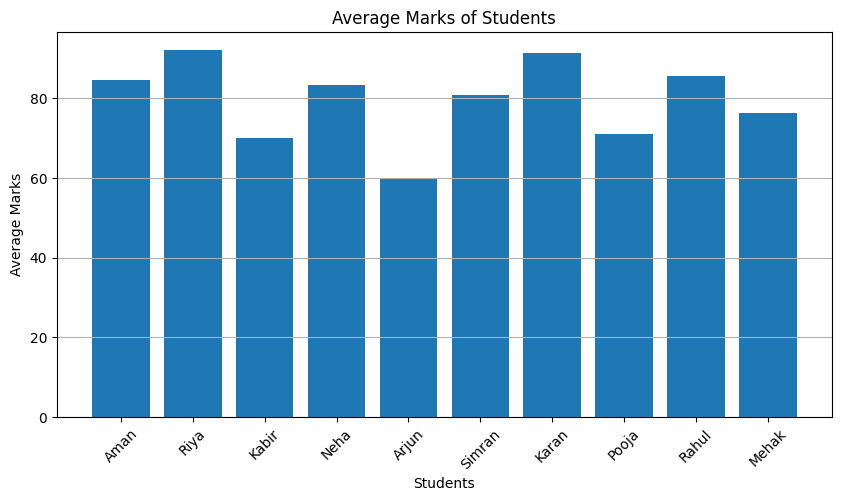

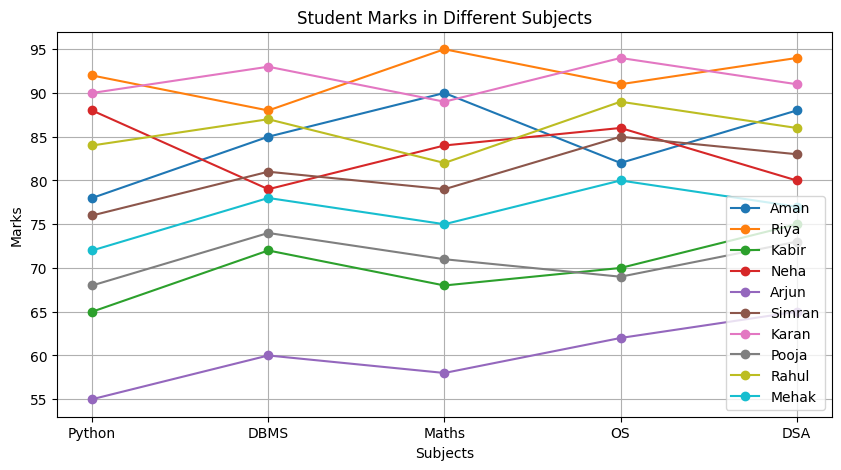

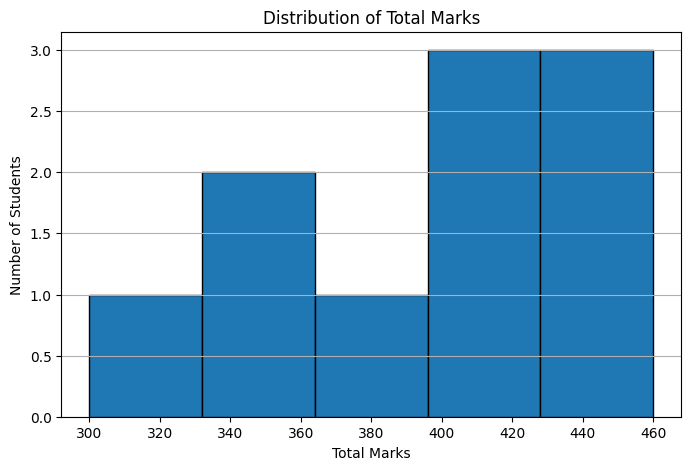

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# Student names
students = [
    "Aman", "Riya", "Kabir", "Neha", "Arjun",
    "Simran", "Karan", "Pooja", "Rahul", "Mehak"
]

# Subjects
subjects = ["Python", "DBMS", "Maths", "OS", "DSA"]

# Marks of 10 students in 5 subjects
marks = np.array([
    [78, 85, 90, 82, 88],
    [92, 88, 95, 91, 94],
    [65, 72, 68, 70, 75],
    [88, 79, 84, 86, 80],
    [55, 60, 58, 62, 65],
    [76, 81, 79, 85, 83],
    [90, 93, 89, 94, 91],
    [68, 74, 71, 69, 73],
    [84, 87, 82, 89, 86],
    [72, 78, 75, 80, 77]
])


# Calculate student averages and total marks
student_average = np.mean(marks, axis=1)
total_marks = np.sum(marks, axis=1)


# 1. Bar chart - average marks of students
plt.figure(figsize=(10, 5))

plt.bar(students, student_average)

plt.title("Average Marks of Students")
plt.xlabel("Students")
plt.ylabel("Average Marks")
plt.xticks(rotation=45)
plt.grid(axis="y")

plt.show()


# 2. Line graph - marks in different subjects
plt.figure(figsize=(10, 5))

for i in range(len(students)):
    plt.plot(
        subjects,
        marks[i],
        marker="o",
        label=students[i]
    )

plt.title("Student Marks in Different Subjects")
plt.xlabel("Subjects")
plt.ylabel("Marks")
plt.legend()
plt.grid()

plt.show()


# 3. Histogram - distribution of total marks
plt.figure(figsize=(8, 5))

plt.hist(total_marks, bins=5, edgecolor="black")

plt.title("Distribution of Total Marks")
plt.xlabel("Total Marks")
plt.ylabel("Number of Students")
plt.grid(axis="y")

plt.show()

In [28]:
#Question 12

Highest-sales month: Jun
Sales: 45000


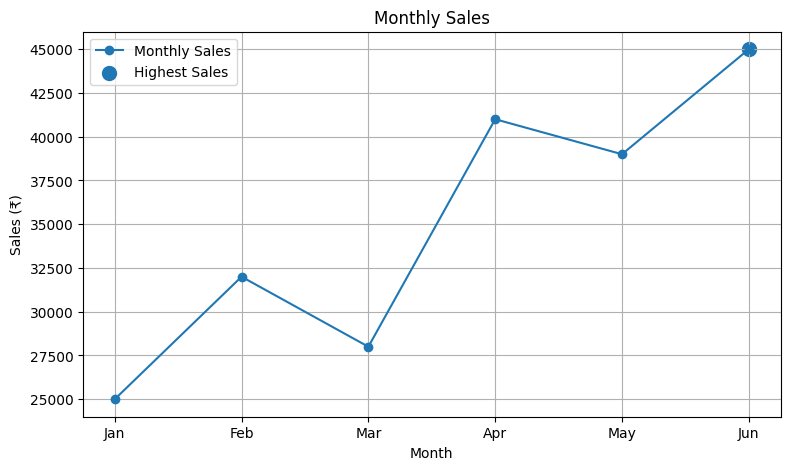

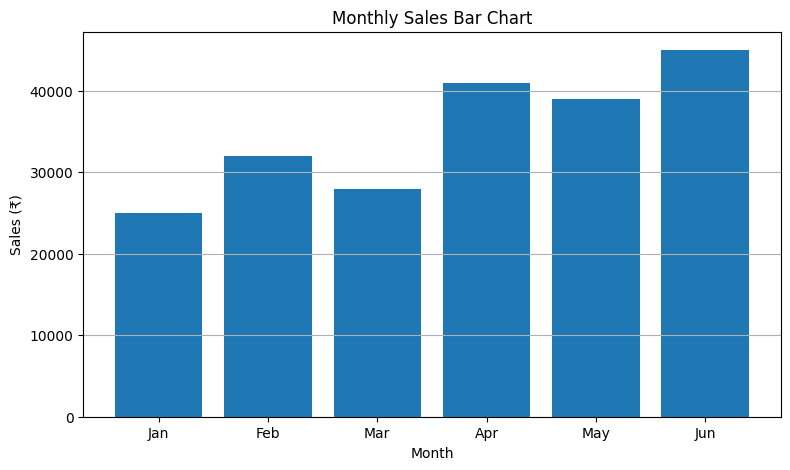

In [29]:
import matplotlib.pyplot as plt

months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']
sales = [25000, 32000, 28000, 41000, 39000, 45000]

# Find highest-sales month
highest_index = sales.index(max(sales))

print("Highest-sales month:", months[highest_index])
print("Sales:", sales[highest_index])


# 1. Line plot
plt.figure(figsize=(9, 5))

plt.plot(
    months,
    sales,
    marker="o",
    label="Monthly Sales"
)

plt.scatter(
    months[highest_index],
    sales[highest_index],
    s=100,
    label="Highest Sales"
)

plt.title("Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Sales (₹)")
plt.legend()
plt.grid()

plt.show()


# 2. Bar chart
plt.figure(figsize=(9, 5))

plt.bar(months, sales)

plt.title("Monthly Sales Bar Chart")
plt.xlabel("Month")
plt.ylabel("Sales (₹)")
plt.grid(axis="y")

plt.show()

In [30]:
#Question 13

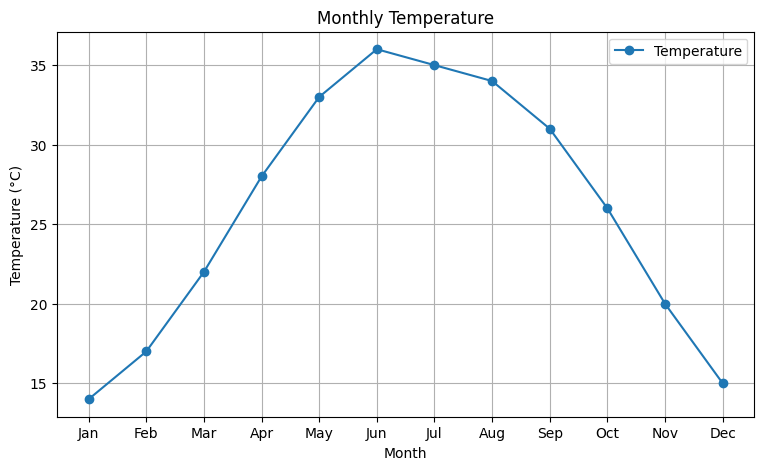

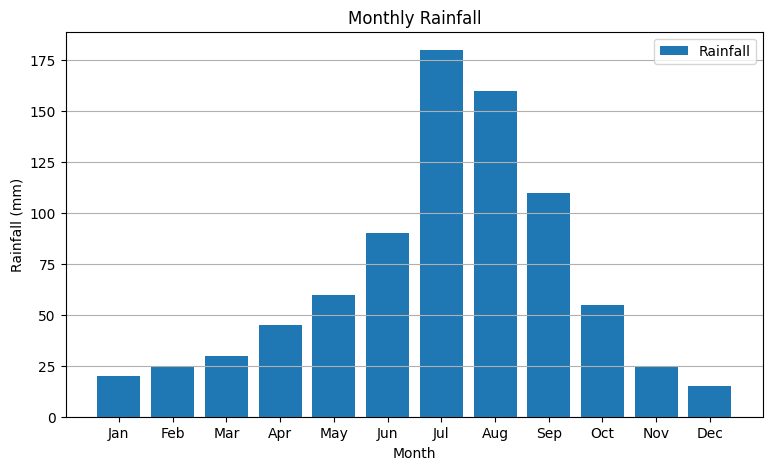

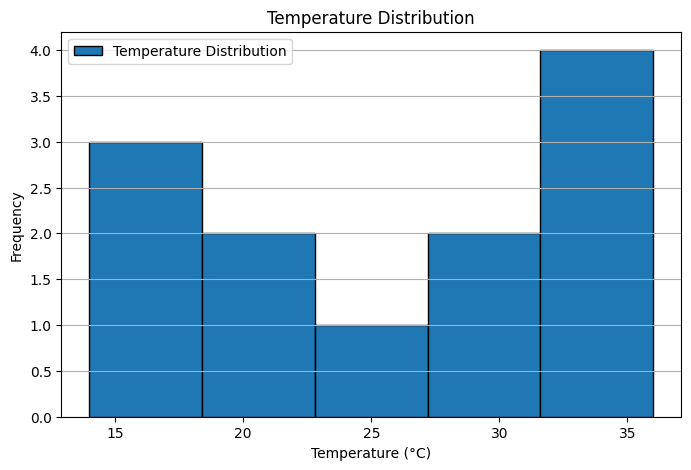

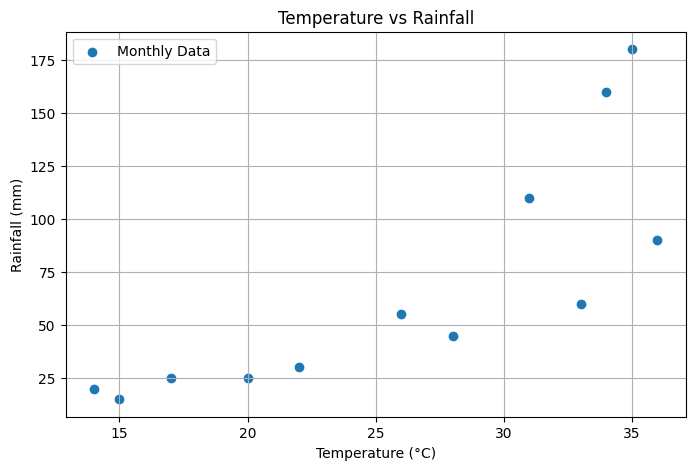

In [31]:
import matplotlib.pyplot as plt

months = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

temperature = [14, 17, 22, 28, 33, 36, 35, 34, 31, 26, 20, 15]

rainfall = [20, 25, 30, 45, 60, 90, 180, 160, 110, 55, 25, 15]


# 1. Line graph of temperature
plt.figure(figsize=(9, 5))

plt.plot(
    months,
    temperature,
    marker="o",
    label="Temperature"
)

plt.title("Monthly Temperature")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid()

plt.show()


# 2. Bar chart of rainfall
plt.figure(figsize=(9, 5))

plt.bar(
    months,
    rainfall,
    label="Rainfall"
)

plt.title("Monthly Rainfall")
plt.xlabel("Month")
plt.ylabel("Rainfall (mm)")
plt.legend()
plt.grid(axis="y")

plt.show()


# 3. Histogram of temperature
plt.figure(figsize=(8, 5))

plt.hist(
    temperature,
    bins=5,
    edgecolor="black",
    label="Temperature Distribution"
)

plt.title("Temperature Distribution")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(axis="y")

plt.show()


# 4. Scatter plot of temperature vs rainfall
plt.figure(figsize=(8, 5))

plt.scatter(
    temperature,
    rainfall,
    label="Monthly Data"
)

plt.title("Temperature vs Rainfall")
plt.xlabel("Temperature (°C)")
plt.ylabel("Rainfall (mm)")
plt.legend()
plt.grid()

plt.show()

In [32]:
#Question 14

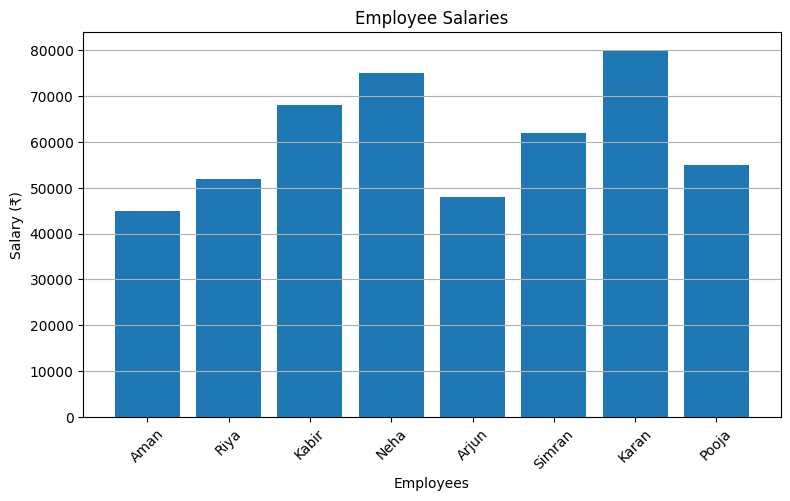

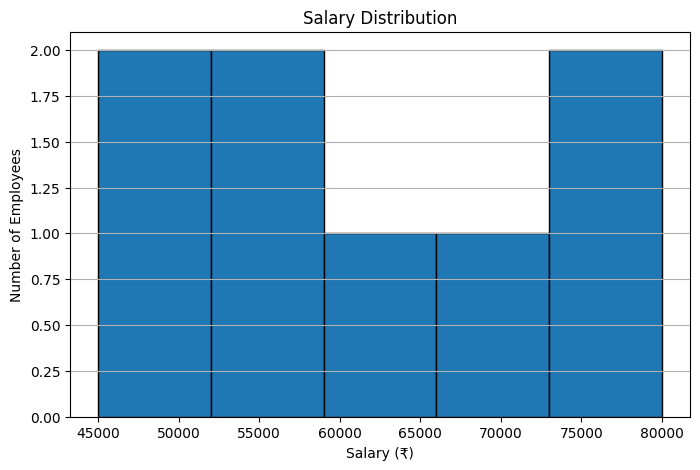

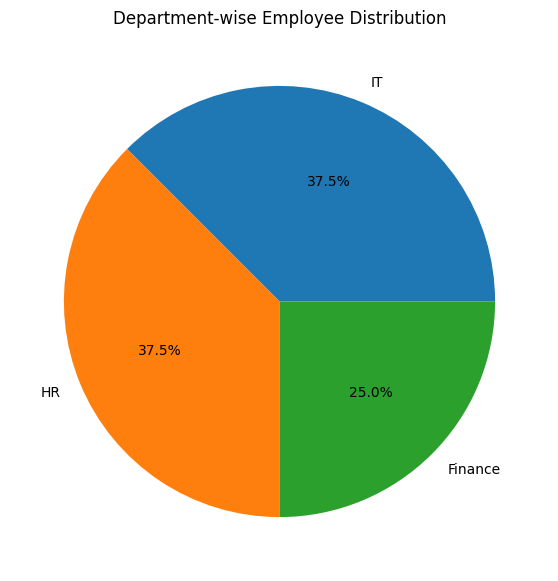

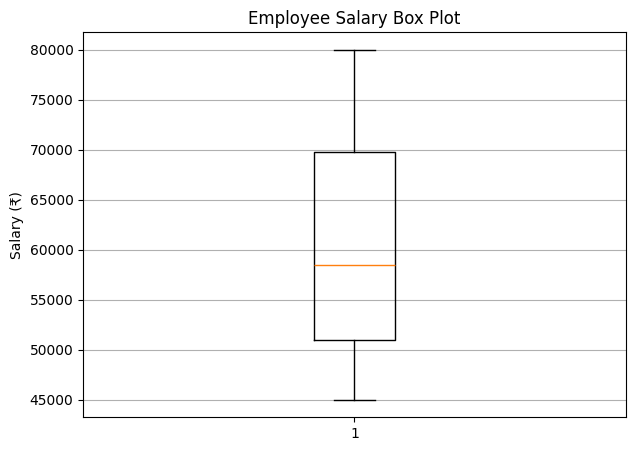

In [33]:
import matplotlib.pyplot as plt

employees = [
    "Aman", "Riya", "Kabir", "Neha",
    "Arjun", "Simran", "Karan", "Pooja"
]

salaries = [
    45000, 52000, 68000, 75000,
    48000, 62000, 80000, 55000
]

departments = [
    "IT", "HR", "IT", "Finance",
    "HR", "IT", "Finance", "HR"
]


# 1. Bar chart of employee salaries
plt.figure(figsize=(9, 5))

plt.bar(employees, salaries)

plt.title("Employee Salaries")
plt.xlabel("Employees")
plt.ylabel("Salary (₹)")
plt.xticks(rotation=45)
plt.grid(axis="y")

plt.show()


# 2. Histogram of salary distribution
plt.figure(figsize=(8, 5))

plt.hist(
    salaries,
    bins=5,
    edgecolor="black"
)

plt.title("Salary Distribution")
plt.xlabel("Salary (₹)")
plt.ylabel("Number of Employees")
plt.grid(axis="y")

plt.show()


# 3. Pie chart of department-wise employee distribution
department_count = {}

for department in departments:
    department_count[department] = department_count.get(department, 0) + 1

plt.figure(figsize=(7, 7))

plt.pie(
    department_count.values(),
    labels=department_count.keys(),
    autopct="%1.1f%%"
)

plt.title("Department-wise Employee Distribution")

plt.show()


# 4. Box plot of salaries
plt.figure(figsize=(7, 5))

plt.boxplot(salaries)

plt.title("Employee Salary Box Plot")
plt.ylabel("Salary (₹)")
plt.grid(axis="y")

plt.show()